In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from astropy.io import fits
import os,sys

In [2]:
# continuously load modules (for the python external codes)
%load_ext autoreload
%autoreload 2

In [3]:
#Add the ppxf lib path
sys.path.append(".")

In [4]:
from corviche import *

In [5]:
corviche()

Using SN_MEDIAN_ALL = 20
spectrum saved in ./spec-syntetic_spec-type2-z0.8-sn20.fits


## Open the fits file

In [6]:
syn_spec='././spec-syntetic_spec-type2-z0.8-sn20.fits'
hdu=fits.open(syn_spec)

In [7]:
header=hdu[0].header
header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
ID_NAME = 'synthetic_AGN'      / synthetic                                      
AGN_TYPE=                    2 / AGN type                                       
Z       =                  0.8 / fixed redshift                                 
BUNIT   = '1E-17 erg/cm^2/s/Ang' / units                                        
SOFTWARE= 'CORVICHE'           / software                                       

In [8]:
file_data=hdu[2].header
file_data

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   36 / length of dimension 1                          
NAXIS2  =                    1 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    9 / number of table fields                         
TTYPE1  = 'Z       '                                                            
TFORM1  = 'E       '                                                            
TTYPE2  = 'SN_MEDIAN_ALL'                                                       
TFORM2  = 'E       '                                                            
TTYPE3  = 'pl_slope'        

In [9]:
hdu[2].data['SN_MEDIAN_ALL']

array([20.01022], dtype='>f4')

In [10]:
data=hdu[1].data
wave=10**data['loglam']
flux=data['flux']
z=hdu[2].data['z']

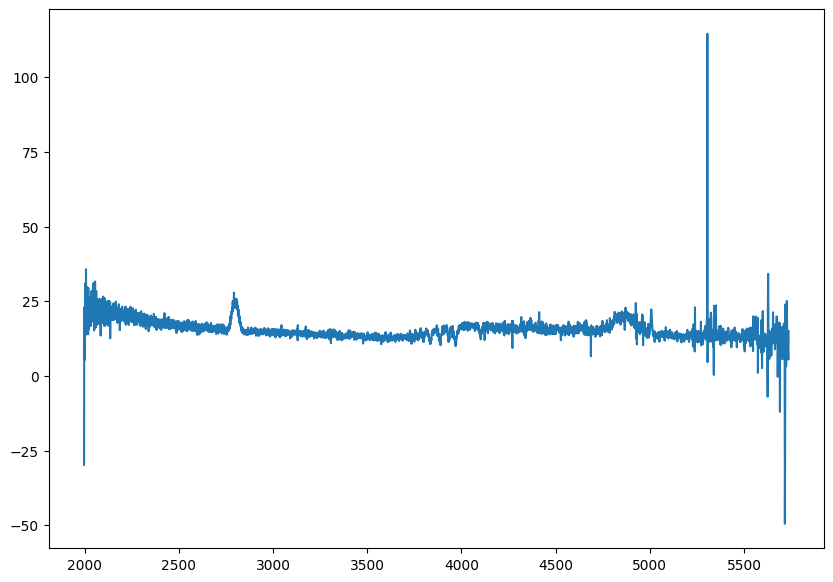

In [11]:
plt.figure(figsize=(10,7))
plt.plot(wave/(1+z),flux)